<a href="https://colab.research.google.com/github/aaradhyajain1110/Assignments-celebal-internship/blob/main/week3%3CAaradhya_Jain%3E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1) Install & Import Required Libraries

In this step we install and import all necessary Python libraries:
- **pandas & numpy** for data manipulation
- **matplotlib & seaborn** for visualization
- **scikit-learn** for scaling, clustering, PCA and evaluation metrics


In [1]:
# Block 1: Install and Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn version check: OK")

 All libraries imported successfully!
NumPy: 2.0.2
Pandas: 2.2.2
Scikit-learn version check: OK


## 2) Load the Dataset

We load the Country-data.csv dataset directly from Kaggle using
the kagglehub API. The dataset contains 167 countries with 10
socio-economic and health features used to determine the overall
development level of each country.

In [2]:
# Block 2: Load Dataset via Kaggle Hub
# Install kagglehub first
!pip install kagglehub -q

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load the dataset directly from Kaggle
file_path = "Country-data.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "rohan0301/unsupervised-learning-on-country-data",
    file_path,
)

print(" Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nFirst 5 records:")
print(df.head())

100%|██████████| 9.01k/9.01k [00:00<00:00, 9.28MB/s]

 Dataset loaded successfully!
Shape: (167, 10)

Column Names: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

First 5 records:
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


## 3) Quick Inspection

In [3]:
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


In [4]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 4) Data Cleaning

We perform the following cleaning steps:
- **Strip whitespace** from all column names
- **Drop duplicate** records to ensure data integrity
- **Force numeric types** on all feature columns
- **Impute missing values** using median of each feature column
  (median is preferred over mean as it is robust to outliers)

In [5]:
# Block 3: Data Cleaning
print("="*50)
print("STEP 1: Strip whitespace from column names")
print("="*50)
df.columns = df.columns.str.strip()
print(f" Columns after stripping: {df.columns.tolist()}")

print("\n" + "="*50)
print("STEP 2: Check & Drop Duplicate Records")
print("="*50)
print(f"Duplicates before: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicates after: {df.duplicated().sum()}")
print(f"Shape after dropping duplicates: {df.shape}")

print("\n" + "="*50)
print("STEP 3: Force Numeric Types on all columns except country")
print("="*50)
numeric_cols = ['child_mort', 'exports', 'health', 'imports',
                'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print(f" Numeric conversion done")
print(df.dtypes)

print("\n" + "="*50)
print("STEP 4: Check & Impute Missing Values with Median")
print("="*50)
print(f"Missing values before imputation:\n{df.isnull().sum()}")
for col in numeric_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
print(f"\nMissing values after imputation:\n{df.isnull().sum()}")
print("\n Data Cleaning Complete!")
print(f"Final Shape: {df.shape}")

STEP 1: Strip whitespace from column names
 Columns after stripping: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

STEP 2: Check & Drop Duplicate Records
Duplicates before: 0
Duplicates after: 0
Shape after dropping duplicates: (167, 10)

STEP 3: Force Numeric Types on all columns except country
 Numeric conversion done
country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

STEP 4: Check & Impute Missing Values with Median
Missing values before imputation:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Missing values after imputation:
country       0
child_mort    0
exports       0
health        0
imports       0
i

## 5) Exploratory Data Analysis - Correlation Heatmap

A correlation heatmap shows the linear relationships between all
numeric features. Values close to +1 indicate strong positive
correlation, values close to -1 indicate strong negative
correlation, and values near 0 indicate no linear relationship.

Key findings:
- child_mort & life_expec = -0.89 (strong negative)
- income & gdpp = +0.90 (strong positive)
- child_mort & total_fer = +0.85 (strong positive)

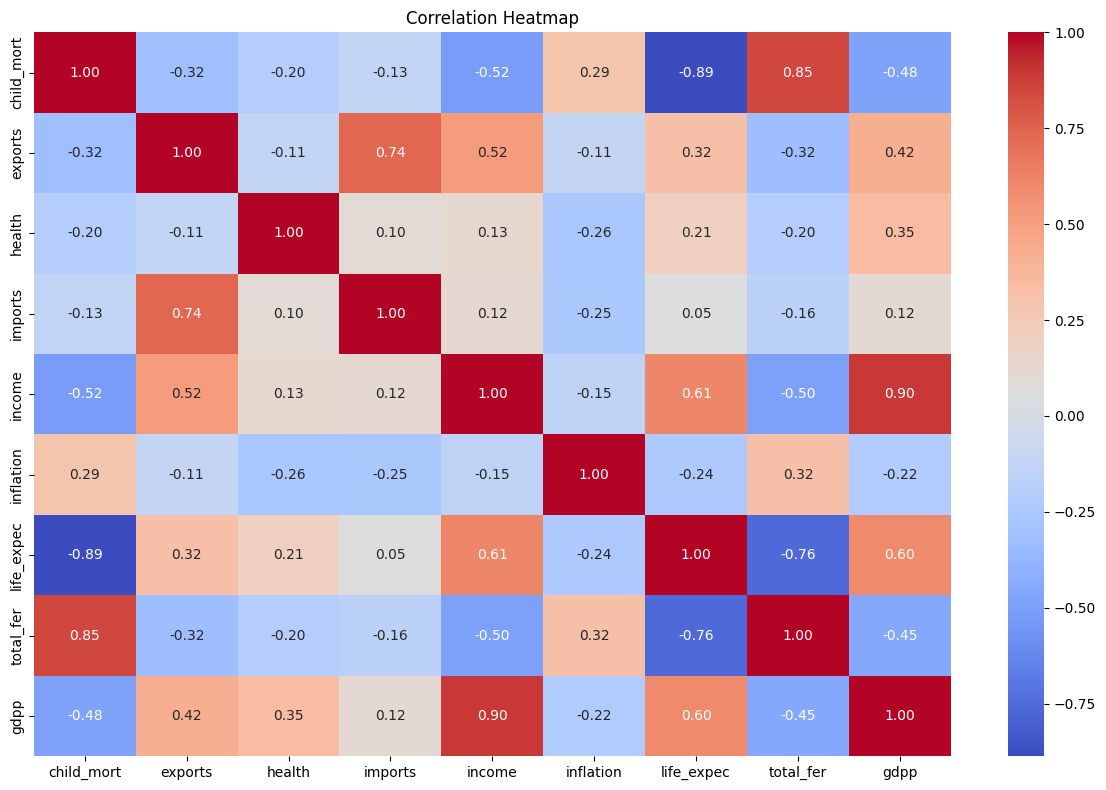

In [6]:
# Section a: Corrected Correlation Heatmap (original features only)
original_numeric = ['child_mort', 'exports', 'health', 'imports',
                    'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

plt.figure(figsize=(12, 8))
sns.heatmap(df[original_numeric].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 6) Exploratory Data Analysis - Boxplots

Boxplots help us visualize the distribution of each feature and
identify outliers. The box represents the interquartile range
(IQR), the line inside the box is the median, and points outside
the whiskers are potential outliers.

This helps us understand:
- The spread and skewness of each feature
- Which features contain extreme outlier values
- Whether scaling is necessary before clustering

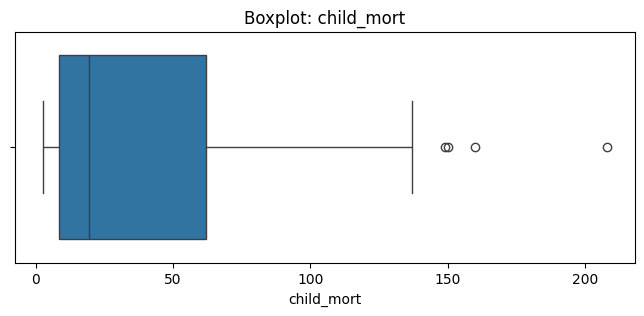

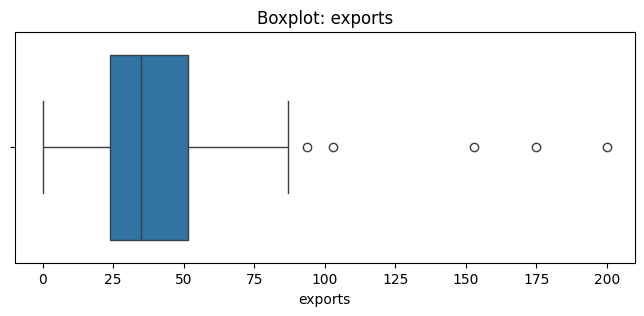

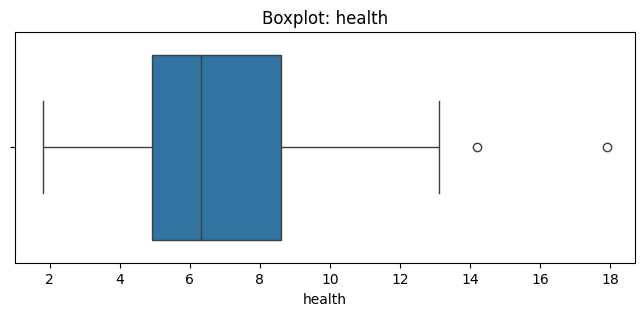

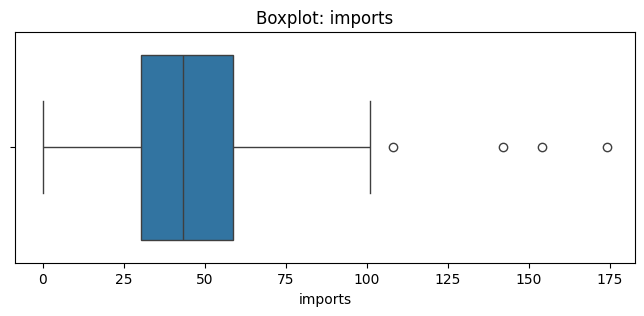

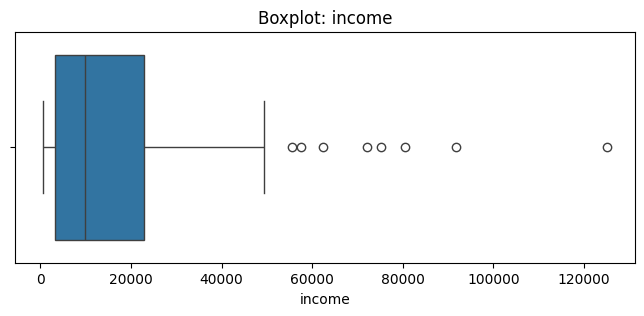

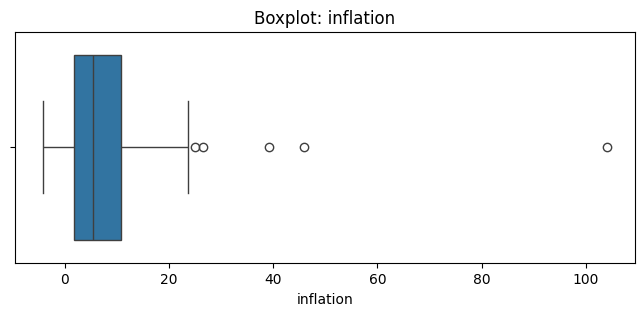

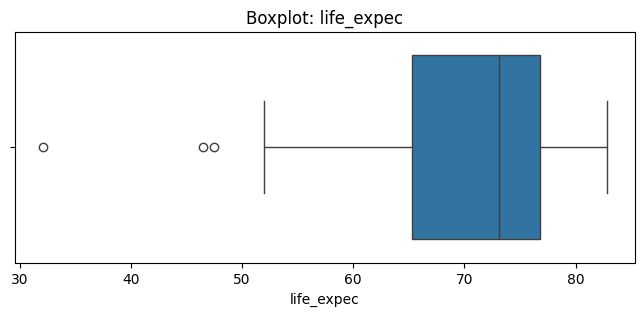

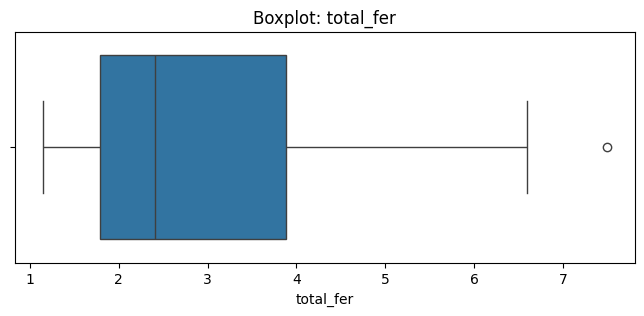

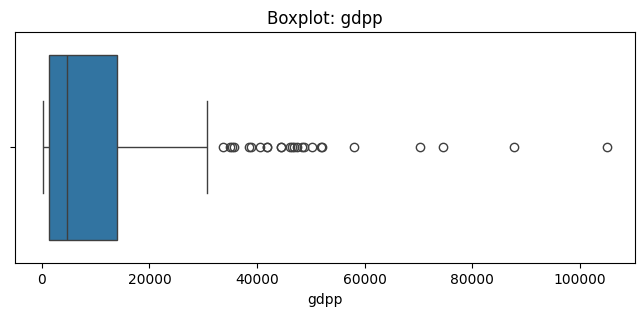

In [7]:
# Section: Boxplots for all numeric columns
numeric_cols = [c for c in df.columns if c != 'country']

for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

## 7) Feature Scaling using StandardScaler

Since clustering algorithms like KMeans are distance-based,
features with larger ranges can dominate the distance calculations.
We apply StandardScaler to normalize all features to:
- Mean = 0
- Standard Deviation = 1

This ensures all 9 features contribute equally to the clustering.

In [8]:
# Block 4: Strip Country Name & Scale Features using StandardScaler

print("="*50)
print("STEP 1: Isolate Country Names & Extract Features")
print("="*50)

# Save country names separately
country_names = df['country']

# Drop country column to get only numeric features
X = df.drop('country', axis=1)

print(f" Country names saved: {len(country_names)} countries")
print(f" Feature matrix shape: {X.shape}")
print(f"Features: {X.columns.tolist()}")

print("\n" + "="*50)
print("STEP 2: Apply StandardScaler")
print("="*50)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f" Scaling complete!")
print(f"\nBefore Scaling (first 3 rows):")
print(X.head(3).to_string())
print(f"\nAfter Scaling (first 3 rows):")
print(X_scaled_df.head(3).round(4).to_string())
print(f"\nMean after scaling (should be ~0): {X_scaled_df.mean().round(4).tolist()}")
print(f"Std after scaling  (should be ~1): {X_scaled_df.std().round(4).tolist()}")

STEP 1: Isolate Country Names & Extract Features
 Country names saved: 167 countries
 Feature matrix shape: (167, 9)
Features: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

STEP 2: Apply StandardScaler
 Scaling complete!

Before Scaling (first 3 rows):
   child_mort  exports  health  imports  income  inflation  life_expec  total_fer  gdpp
0        90.2     10.0    7.58     44.9    1610       9.44        56.2       5.82   553
1        16.6     28.0    6.55     48.6    9930       4.49        76.3       1.65  4090
2        27.3     38.4    4.17     31.4   12900      16.10        76.5       2.89  4460

After Scaling (first 3 rows):
   child_mort  exports  health  imports  income  inflation  life_expec  total_fer    gdpp
0      1.2915  -1.1383  0.2791  -0.0825 -0.8082     0.1573     -1.6191     1.9029 -0.6792
1     -0.5389  -0.4797 -0.0970   0.0708 -0.3754    -0.3123      0.6479    -0.8600 -0.4856
2     -0.2728  -0.0991 -0.9661  -0

## 8) Finding Optimal K - Elbow Method

We run KMeans for k values ranging from 2 to 10 and record the
inertia (within-cluster sum of squares) for each k. The optimal k
is found at the "elbow point" where inertia stops decreasing
significantly. A lower inertia means more compact clusters.

Result: The elbow curve shows a clear bend at k=3, confirming
3 as our optimal number of clusters.

Running KMeans for k = 2 to 10...
  k=2 → Inertia: 1050.21
  k=3 → Inertia: 831.42
  k=4 → Inertia: 700.52
  k=5 → Inertia: 620.16
  k=6 → Inertia: 558.47
  k=7 → Inertia: 495.81
  k=8 → Inertia: 457.59
  k=9 → Inertia: 427.80
  k=10 → Inertia: 403.23

 Inertia values collected!


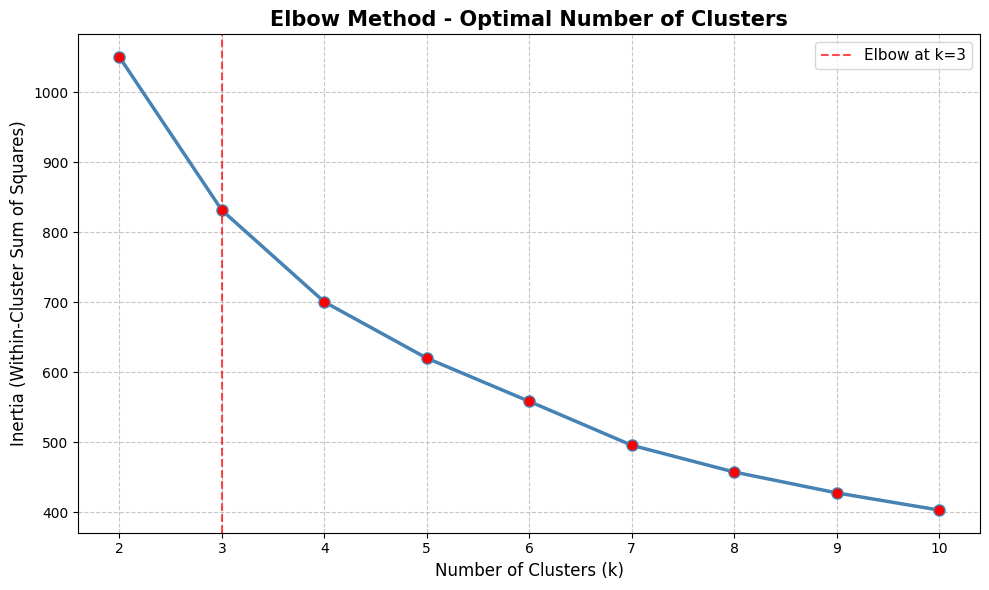


 Elbow curve plotted & saved!


In [9]:
# Block 5: Elbow Method - Finding Optimal K

print("="*50)
print("Running KMeans for k = 2 to 10...")
print("="*50)

inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    print(f"  k={k} → Inertia: {kmeans.inertia_:.2f}")

print("\n Inertia values collected!")

# Plot Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o', color='steelblue',
         linewidth=2.5, markersize=8, markerfacecolor='red')
plt.title('Elbow Method - Optimal Number of Clusters', fontsize=15, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)

# Mark the elbow point at k=3
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Elbow at k=3')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150)
plt.show()
print("\n Elbow curve plotted & saved!")

## 9) Training KMeans Model (best_k = 3)

We train the final KMeans model with:
- n_clusters = 3 (determined from elbow method)
- random_state = 42 (for reproducibility)
- n_init = 10 (runs algorithm 10 times, picks best result)

The model assigns each of the 167 countries to one of 3 clusters
based on their socio-economic and health feature similarities.

In [10]:
# Block 6: Train Final KMeans Model with best_k = 3

print("="*50)
print("Training KMeans with best_k = 3")
print("="*50)

# Define best k and train model
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Assign cluster labels back to original dataframe
df['cluster'] = kmeans.labels_

print(f" KMeans model trained successfully!")
print(f"   Number of clusters: {best_k}")
print(f"   Random state: 42")
print(f"   n_init: 10")

print("\n" + "="*50)
print("Cluster Distribution")
print("="*50)
cluster_counts = df['cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    print(f"  Cluster {cluster}: {count} countries")

print("\n" + "="*50)
print("Sample Countries per Cluster")
print("="*50)
for cluster in range(best_k):
    countries = df[df['cluster'] == cluster]['country'].tolist()
    print(f"\n  Cluster {cluster} ({len(countries)} countries):")
    print(f"  {countries[:8]}...")  # Show first 8 countries

print("\n" + "="*50)
print("Cluster Centers (Scaled Features)")
print("="*50)
centers_df = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)
print(centers_df.round(3).to_string())

Training KMeans with best_k = 3
 KMeans model trained successfully!
   Number of clusters: 3
   Random state: 42
   n_init: 10

Cluster Distribution
  Cluster 0: 36 countries
  Cluster 1: 47 countries
  Cluster 2: 84 countries

Sample Countries per Cluster

  Cluster 0 (36 countries):
  ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic']...

  Cluster 1 (47 countries):
  ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic']...

  Cluster 2 (84 countries):
  ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh']...

Cluster Centers (Scaled Features)
   child_mort  exports  health  imports  income  inflation  life_expec  total_fer   gdpp
0      -0.827    0.645   0.727    0.191   1.484     -0.485       1.080     -0.792  1.616
1       1.360   -0.438  -0.156   -0.189  -0.687      0.402      -1.282      1.365 -0.604
2      -0.406   -0.03

## 10) Evaluating Clustering Performance - Silhouette Score

The Silhouette Score measures how well each point fits its assigned
cluster compared to other clusters. Score ranges from -1 to +1:
- Score near +1 = well separated clusters
- Score near 0  = overlapping clusters
- Score near -1 = misclassified points

Our Score: 0.2833 — acceptable for real-world country data where
natural socio-economic overlaps between nations are expected.

In [11]:
# Block 7: Evaluate Clustering Performance - Silhouette Score

print("="*50)
print("Evaluating KMeans Clustering Performance")
print("="*50)

# Calculate Silhouette Score
sil_score = silhouette_score(X_scaled, kmeans.labels_)

print(f"\n Silhouette Score: {sil_score:.4f}")

# Interpret the score
print("\n" + "="*50)
print("Score Interpretation")
print("="*50)
if sil_score >= 0.71:
    interpretation = "Strong Structure "
elif sil_score >= 0.51:
    interpretation = "Reasonable Structure "
elif sil_score >= 0.26:
    interpretation = "Weak Structure "
else:
    interpretation = "No Structure "

print(f"  Score Range : -1 (worst) to +1 (best)")
print(f"  Your Score  : {sil_score:.4f}")
print(f"  Verdict     : {interpretation}")

print("\n" + "="*50)
print("Cluster-wise Summary Statistics")
print("="*50)
cluster_summary = df.groupby('cluster')[['child_mort', 'income',
                                          'life_expec', 'gdpp',
                                          'total_fer']].mean().round(2)
cluster_summary.index = [f'Cluster {i}' for i in cluster_summary.index]
print(cluster_summary.to_string())

print("\n" + "="*50)
print("Cluster Interpretation")
print("="*50)
print("""
  Cluster 0 → High Income / Developed Countries
              (High GDPP, High Life Expectancy, Low Child Mortality)

  Cluster 1 → Low Income / Underdeveloped Countries
              (High Child Mortality, Low Income, Low Life Expectancy)

  Cluster 2 → Middle Income / Developing Countries
              (Moderate values across all features)
""")

Evaluating KMeans Clustering Performance

 Silhouette Score: 0.2833

Score Interpretation
  Score Range : -1 (worst) to +1 (best)
  Your Score  : 0.2833
  Verdict     : Weak Structure 

Cluster-wise Summary Statistics
           child_mort    income  life_expec      gdpp  total_fer
Cluster 0        5.00  45672.22       80.13  42494.44       1.75
Cluster 1       92.96   3942.40       59.19   1922.38       5.01
Cluster 2       21.93  12305.60       72.81   6486.45       2.31

Cluster Interpretation

  Cluster 0 → High Income / Developed Countries
              (High GDPP, High Life Expectancy, Low Child Mortality)

  Cluster 1 → Low Income / Underdeveloped Countries
              (High Child Mortality, Low Income, Low Life Expectancy)

  Cluster 2 → Middle Income / Developing Countries
              (Moderate values across all features)



## 11) Secondary Clustering - DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
is used as a comparative clustering method. Unlike KMeans it:
- Does NOT require specifying k upfront
- Automatically detects outliers (label = -1)
- Can find clusters of arbitrary shapes

Parameters used:
- eps = 1.5 (maximum distance between two points in a cluster)
- min_samples = 5 (minimum points to form a dense region)

Result: 1 main cluster + 30 outlier countries identified.

In [12]:
# Block 8: DBSCAN Clustering (eps=1.5, min_samples=5)

print("="*50)
print("Training DBSCAN Model")
print("="*50)

# Train DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Add DBSCAN labels to dataframe
df['dbscan_cluster'] = dbscan_labels

print(f" DBSCAN model trained successfully!")
print(f"   eps         : 1.5")
print(f"   min_samples : 5")

print("\n" + "="*50)
print("DBSCAN Cluster Distribution")
print("="*50)
unique_labels = sorted(set(dbscan_labels))
for label in unique_labels:
    count = list(dbscan_labels).count(label)
    label_name = "Noise/Outliers " if label == -1 else f"Cluster {label}"
    print(f"  {label_name}: {count} countries")

print("\n" + "="*50)
print("Noise/Outlier Countries (label = -1)")
print("="*50)
noise_countries = df[df['dbscan_cluster'] == -1]['country'].tolist()
print(f"  Count : {len(noise_countries)}")
print(f"  Countries: {noise_countries}")

print("\n" + "="*50)
print("KMeans vs DBSCAN Comparison")
print("="*50)
print(f"  KMeans  → {best_k} clusters, 0 outliers")
print(f"  DBSCAN  → {len([l for l in unique_labels if l != -1])} clusters, "
      f"{list(dbscan_labels).count(-1)} outliers")
print("""
  Key Differences:
  • KMeans  : Forces every point into a cluster
  • DBSCAN  : Detects outliers & arbitrary shapes
  • KMeans  : Needs k specified upfront
  • DBSCAN  : Automatically finds cluster count
""")

Training DBSCAN Model
 DBSCAN model trained successfully!
   eps         : 1.5
   min_samples : 5

DBSCAN Cluster Distribution
  Noise/Outliers : 30 countries
  Cluster 0: 137 countries

Noise/Outlier Countries (label = -1)
  Count : 30
  Countries: ['Angola', 'Brunei', 'Central African Republic', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Equatorial Guinea', 'Gabon', 'Haiti', 'Iraq', 'Ireland', 'Kiribati', 'Kuwait', 'Lesotho', 'Liberia', 'Luxembourg', 'Malta', 'Micronesia, Fed. Sts.', 'Mongolia', 'Nigeria', 'Norway', 'Qatar', 'Rwanda', 'Seychelles', 'Sierra Leone', 'Singapore', 'South Africa', 'Timor-Leste', 'Turkmenistan', 'United States', 'Venezuela']

KMeans vs DBSCAN Comparison
  KMeans  → 3 clusters, 0 outliers
  DBSCAN  → 1 clusters, 30 outliers

  Key Differences:
  • KMeans  : Forces every point into a cluster
  • DBSCAN  : Detects outliers & arbitrary shapes
  • KMeans  : Needs k specified upfront
  • DBSCAN  : Automatically finds cluster count



## 12) PCA 2D Visualization

Principal Component Analysis (PCA) reduces the 9 dimensional
feature space down to 2 dimensions for visualization while
preserving maximum variance.

- PC1 captures 45.95% of variance (economic development axis)
- PC2 captures 17.18% of variance (trade patterns axis)
- Total variance explained: 63.13%

KMeans cluster labels are mapped to colors to show how well
the clusters are separated in 2D space.

Applying PCA - Reducing to 2 Dimensions
 PCA completed!
   PC1 Variance Explained : 45.95%
   PC2 Variance Explained : 17.18%
   Total Variance Captured: 63.13%

Plotting PCA Scatterplot with KMeans Labels


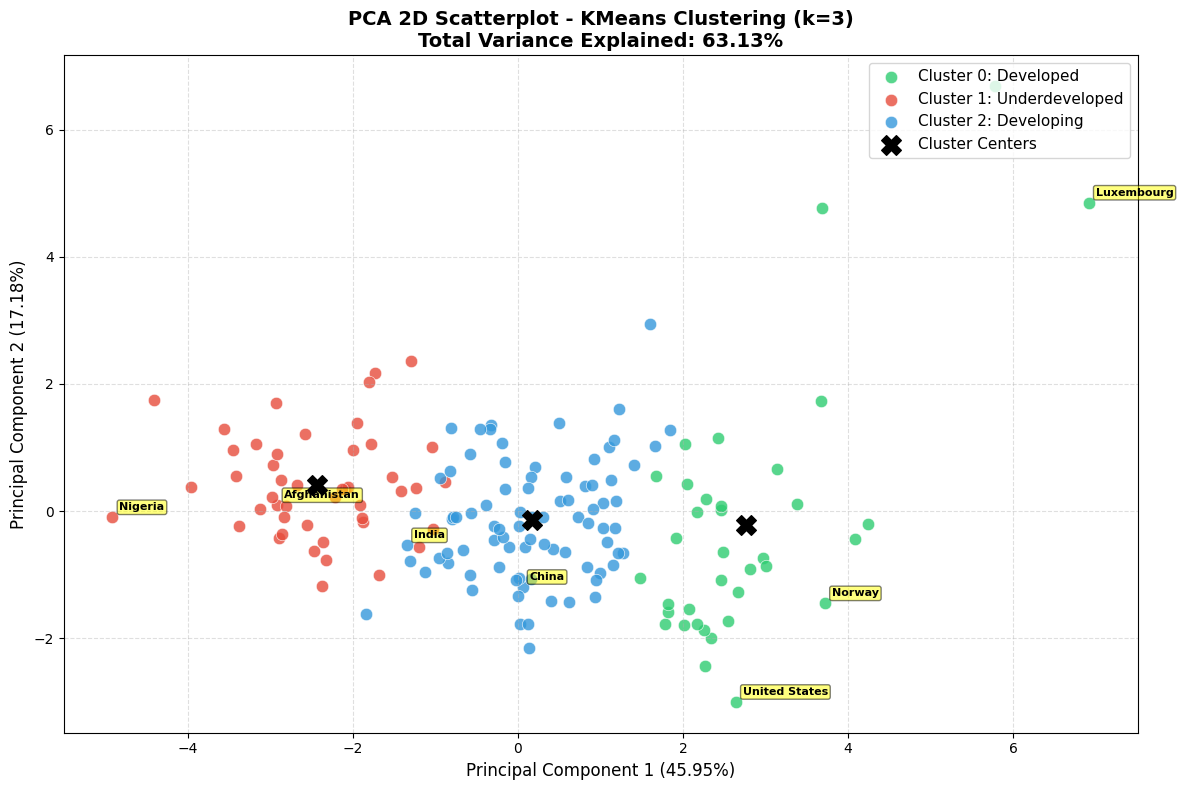


 PCA Scatterplot plotted & saved!


In [13]:
# Block 9: PCA 2D Projection + KMeans Color-Coded Scatterplot

print("="*50)
print("Applying PCA - Reducing to 2 Dimensions")
print("="*50)

# Apply PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Variance explained
var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100
total_var = var1 + var2

print(f" PCA completed!")
print(f"   PC1 Variance Explained : {var1:.2f}%")
print(f"   PC2 Variance Explained : {var2:.2f}%")
print(f"   Total Variance Captured: {total_var:.2f}%")

print("\n" + "="*50)
print("Plotting PCA Scatterplot with KMeans Labels")
print("="*50)

# Color and label mappings
colors = {0: '#2ecc71', 1: '#e74c3c', 2: '#3498db'}
labels = {0: 'Cluster 0: Developed',
          1: 'Cluster 1: Underdeveloped',
          2: 'Cluster 2: Developing'}

fig, ax = plt.subplots(figsize=(12, 8))

for cluster in range(best_k):
    mask = kmeans.labels_ == cluster
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[cluster],
        label=labels[cluster],
        s=80, alpha=0.8, edgecolors='white', linewidth=0.5
    )

# Annotate a few notable countries
notable = ['United States', 'China', 'Afghanistan', 'Norway',
           'Nigeria', 'India', 'Somalia', 'Luxembourg']
for idx, row in df.iterrows():
    if row['country'] in notable:
        ax.annotate(
            row['country'],
            (X_pca[idx, 0], X_pca[idx, 1]),
            fontsize=8, fontweight='bold',
            xytext=(5, 5), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.5)
        )

# Plot cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           c='black', marker='X', s=200, zorder=5, label='Cluster Centers')

ax.set_title(f'PCA 2D Scatterplot - KMeans Clustering (k=3)\n'
             f'Total Variance Explained: {total_var:.2f}%',
             fontsize=14, fontweight='bold')
ax.set_xlabel(f'Principal Component 1 ({var1:.2f}%)', fontsize=12)
ax.set_ylabel(f'Principal Component 2 ({var2:.2f}%)', fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('pca_scatterplot.png', dpi=150)
plt.show()
print("\n PCA Scatterplot plotted & saved!")

## 13) Cluster Profiling

We calculate the mean value of each feature per cluster to
understand the characteristics of each group. This helps us
interpret what each cluster represents in terms of socio-economic
development and identify which countries need the most aid.

In [14]:
# Section 13: Cluster Profiling (Fixed)

# First check what columns exist
print("Available columns:", df.columns.tolist())

# Fix: rename cluster column to kmeans_cluster if needed
if 'cluster' in df.columns and 'kmeans_cluster' not in df.columns:
    df = df.rename(columns={'cluster': 'kmeans_cluster'})
    print("Renamed 'cluster' to 'kmeans_cluster'")

numeric_cols = ['child_mort', 'exports', 'health', 'imports',
                'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile.index = [f'Cluster {i}' for i in profile.index]

print("\n" + "="*60)
print("CLUSTER PROFILE - Mean values per cluster")
print("="*60)
print(profile.to_string())

print("\n" + "="*60)
print("CLUSTER LABELS")
print("="*60)
print("""
  Cluster 0 → Developed Countries
              High GDPP, High Income, Low Child Mortality

  Cluster 1 → Underdeveloped Countries
              High Child Mortality, Low Income, Low Life Expectancy

  Cluster 2 → Developing Countries
              Moderate values across all features
""")

Available columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp', 'cluster', 'dbscan_cluster']
Renamed 'cluster' to 'kmeans_cluster'

CLUSTER PROFILE - Mean values per cluster
           child_mort  exports  health  imports    income  inflation  life_expec  total_fer      gdpp
Cluster 0        5.00    58.74    8.81    51.49  45672.22       2.67       80.13       1.75  42494.44
Cluster 1       92.96    29.15    6.39    42.32   3942.40      12.02       59.19       5.01   1922.38
Cluster 2       21.93    40.24    6.20    47.47  12305.60       7.60       72.81       2.31   6486.45

CLUSTER LABELS

  Cluster 0 → Developed Countries
              High GDPP, High Income, Low Child Mortality

  Cluster 1 → Underdeveloped Countries
              High Child Mortality, Low Income, Low Life Expectancy

  Cluster 2 → Developing Countries
              Moderate values across all features



## 14) Section 14 - Final Insights & Observations

Based on the clustering analysis we identify key socio-economic
patterns across the 3 country clusters to help HELP International
decide how to strategically allocate their $10 million fund.

We address:
- Which cluster has highest child mortality
- Which cluster represents top economic zones
- Which cluster is underdeveloped and needs aid
- Which countries should be prioritized for immediate aid
- What DBSCAN outliers reveal about anomalous economies


**OBSERVATION 1: High-Mortality Cluster (Cluster 1 - Underdeveloped)**

Cluster 1 contains 47 countries with the most critical health indicators.
The average child mortality rate is 92.96 per 1000 live births — nearly 19x
higher than Cluster 0 (5.00). Countries like Afghanistan, Angola, Nigeria,
and Central African Republic fall here. These nations show the lowest average
income ($3,942) and lowest life expectancy (59.19 years). This cluster
represents the HIGHEST PRIORITY for HELP International aid.

**OBSERVATION 2: Top-Tier Economic Zone (Cluster 0 - Developed)**

Cluster 0 contains 36 wealthy nations including Australia, Norway, USA, and
Luxembourg. Average GDP per capita is $42,494 with income averaging $45,672.
Life expectancy reaches 80.13 years with child mortality as low as 5.00.
These countries require NO humanitarian aid and are potential donor nations.

**OBSERVATION 3: Low-Development Middle Ground (Cluster 2 - Developing)**

Cluster 2 is the largest group with 84 countries including India, China,
Algeria and Argentina. Average GDPP is $6,486 with child mortality at 21.93.
Moderate fertility rates (2.31) and life expectancy of 72.81 suggest
improving conditions but targeted investment is still needed.

**OBSERVATION 4: DBSCAN Outlier Insights**

DBSCAN identified 30 outlier countries that don't fit standard development
patterns. These include oil-rich states (Qatar, Kuwait), micro economies
(Luxembourg, Singapore), and extreme poverty cases (Haiti, Sierra Leone).
These require individual assessment rather than group-based aid strategies.

**OBSERVATION 5: PCA & Dimensional Insights**

PCA reduced 9 features to 2 components capturing 63.13% of total variance.
PC1 (45.95%) represents the economic development axis. PC2 (17.18%) captures
trade pattern variation. Clear spatial separation between clusters validates
that KMeans successfully identified meaningful country groupings.